# Data Scaling Effects on CNN and Vision Transformer Performance

## Research question

How does the amount of training data affect the generalization of a
CIFAR-adapted ResNet-18 and a ViT-Tiny trained from scratch on CIFAR-10?

The experiment compares the two model families at 10%, 50%, and 100% of a
fixed training pool. A separate validation set is used for checkpoint selection,
and the official CIFAR-10 test set is evaluated only once for each final model.

The comparison is intended to distinguish three possible explanations for a
performance gap:

1. **Data efficiency:** one architecture may learn more effectively from fewer examples.
2. **Optimization:** a model may still be under-trained under the selected schedule.
3. **Generalization:** a model may fit the training data but fail to transfer to unseen data.

Because ResNet-18 and ViT-Tiny use model-specific optimizers, the results should
be interpreted as performance under the documented training protocols, not as
proof that architecture alone caused every difference.

## Data Preparation

In [1]:
import warnings
warnings.filterwarnings('ignore')

import cv2
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset
from torch.utils.data import DataLoader

import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Download the CIFAR-10 dataset

In PyTorch, the CIFAR-10 dataset has already been splitted into training set and test set.

* Training set: 50,000 images

* Test set: 10,000 images

Training images use random crop and horizontal flip augmentation. Validation
and test images use deterministic normalization only. Keeping evaluation
deterministic ensures that repeated evaluations use the same images and that
differences between models are not caused by random test-time augmentation.

In [2]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Two views of the official training split are required: an augmented view for
# model fitting and a deterministic view for validation.
full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_transform
)
full_train_eval_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=False, transform=eval_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=eval_transform
)

100%|██████████| 170M/170M [05:15<00:00, 541kB/s] 


### Overview of the CIFAR-10 classes

**CIFAR-10 dataset**

CIFAR-10 contains 60,000 color images of size 32x32 across 10 balanced classes.
Each class contains 6,000 images: 5,000 in the official training split and
1,000 in the official test split. The official training split contains 50,000
images in total, while the official test split contains 10,000.

In [4]:
# CIFAR-10 classes name
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

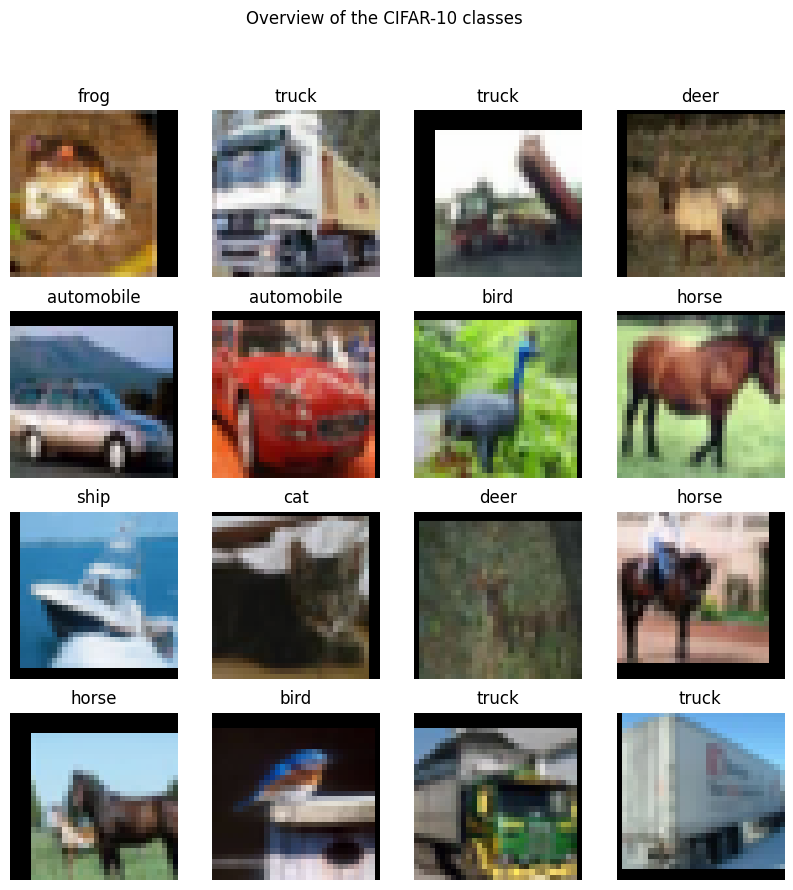

In [5]:
plt.figure(figsize=(10, 10))
# check the first 16 plots in CIFAR-10 dataset
for i in range(16):
    plt.subplot(4, 4, i + 1)

    img_tensor, label = full_train_dataset[i]

    # inverse normalization processing
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = np.clip(img * std + mean, 0, 1)

    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis('off')
plt.suptitle("Overview of the CIFAR-10 classes")
plt.show()

### Create a fixed validation set and nested training subsets

The official 50,000-image training split is first divided into a 45,000-image
training pool and a fixed 5,000-image validation set using stratified sampling.
The 10%, 50%, and 100% experiments are then sampled from the same training pool.

The smaller subsets are nested: the 10% subset is contained in the 50% subset,
which is contained in the 100% subset. This reduces variation caused by using
unrelated samples at different scales. The official 10,000-image test set is
kept untouched until the best validation checkpoint has been selected.

In [6]:
SPLIT_SEED = 42

all_indices = np.arange(len(full_train_dataset))
all_targets = np.asarray(full_train_dataset.targets)

train_pool_indices, val_indices = train_test_split(
    all_indices,
    test_size=5000,
    stratify=all_targets,
    random_state=SPLIT_SEED,
)

# Shuffle the training pool once within each class so that smaller scales are
# nested and remain class-balanced.
rng = np.random.default_rng(SPLIT_SEED)
indices_by_class = {}
for class_id in range(10):
    class_indices = train_pool_indices[all_targets[train_pool_indices] == class_id].copy()
    rng.shuffle(class_indices)
    indices_by_class[class_id] = class_indices


def get_nested_train_indices(ratio):
    selected = []
    for class_id in range(10):
        class_indices = indices_by_class[class_id]
        count = int(len(class_indices) * ratio)
        selected.extend(class_indices[:count])
    return np.asarray(selected)

Define the three training scales and create separate data loaders for training,
validation, and final testing. Only the training loaders shuffle examples and
apply random augmentation.

In [7]:
scales = [0.1, 0.5, 1.0]

trainloaders = {}
for i, scale in enumerate(scales):
    selected_indices = get_nested_train_indices(scale)
    train_subset = Subset(full_train_dataset, selected_indices)
    trainloaders[i] = DataLoader(
        train_subset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
    )

val_subset = Subset(full_train_eval_dataset, val_indices)
valloader = DataLoader(
    val_subset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

testloader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

Verify the number of examples and class balance in every training subset, the
fixed validation set, and the untouched official test set.

In [8]:
print(f"Training pool samples: {len(train_pool_indices)}")
for i, scale in enumerate(scales):
    print(f"{int(scale * 100)}% training subset: {len(trainloaders[i].dataset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Official test samples: {len(test_dataset)}")

images, labels = next(iter(trainloaders[0]))
print(f"\nBatch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

Training pool samples: 45000
10% training subset: 4500
50% training subset: 22500
100% training subset: 45000
Validation samples: 5000
Official test samples: 10000

Batch images shape: torch.Size([64, 3, 32, 32])
Batch labels shape: torch.Size([64])


In [9]:
def class_distribution(indices, targets):
    labels = targets[np.asarray(indices)]
    unique, counts = np.unique(labels, return_counts=True)
    return {int(label): int(count) for label, count in zip(unique, counts)}


for i, scale in enumerate(scales):
    subset_indices = trainloaders[i].dataset.indices
    print(
        f"{int(scale * 100)}% training subset:",
        class_distribution(subset_indices, all_targets),
    )

print("Validation set:", class_distribution(val_indices, all_targets))
test_targets = np.asarray(test_dataset.targets)
print("Official test set:", class_distribution(np.arange(len(test_dataset)), test_targets))

10% training subset: {0: 450, 1: 450, 2: 450, 3: 450, 4: 450, 5: 450, 6: 450, 7: 450, 8: 450, 9: 450}
50% training subset: {0: 2250, 1: 2250, 2: 2250, 3: 2250, 4: 2250, 5: 2250, 6: 2250, 7: 2250, 8: 2250, 9: 2250}
100% training subset: {0: 4500, 1: 4500, 2: 4500, 3: 4500, 4: 4500, 5: 4500, 6: 4500, 7: 4500, 8: 4500, 9: 4500}
Validation set: {0: 500, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}
Official test set: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}


The checks above should show equal class counts at every training scale and in
the validation and test sets. This verifies class balance, but it does not by
itself prove that the models are fairly optimized; optimizer choice, training
budget, model capacity, and random-seed variation must still be documented.

## Model Training

In [10]:
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim

### Training Function

The train_one_epoch function implements a single pass over the training dataset.

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    acc = 100. * correct / total

    return avg_loss, acc

### Evaluation function

The evaluation function runs without gradient updates and is used on the fixed
validation set after every epoch. The official test set is passed to the same
function only once after loading the checkpoint with the best validation
accuracy.

In [12]:
def evaluate(model, loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    acc = 100. * correct / total

    return avg_loss, acc

In [13]:
from copy import deepcopy


def fit_model(model, trainloader, optimizer, scheduler, criterion, device, num_epochs):
    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }
    best_state = None
    best_val_acc = float("-inf")
    best_epoch = None

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, trainloader, optimizer, criterion, device
        )
        val_loss, val_acc = evaluate(model, valloader, criterion, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())

        scheduler.step()

        if epoch <= 5 or epoch % 5 == 0:
            print(
                f"Epoch [{epoch}/{num_epochs}] "
                f"- Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
                f"- Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%"
            )

    model.load_state_dict(best_state)
    history["best_epoch"] = best_epoch
    history["best_val_acc"] = best_val_acc
    return history

### Model Architecture: Convolutional Neural Network (ResNet-18)

To adapt the standard ResNet-18 architecture for the low-resolution CIFAR-10 dataset (32x32 pixels), we implement the following modifications:

1. First Convolutional Layer: We replaced the default 7×7 kernel (stride 2) with a 3×3 kernel (stride 1). This prevents excessive downsampling at the very beginning of the network, which would otherwise lead to significant loss of fine-grained spatial features.

2. Initial Max Pooling: We replaced the initial maxpool layer with an Identity() layer. Removing this pooling step ensures that the feature map dimensions remain large enough for the subsequent residual blocks to extract meaningful patterns.

3. Output Layer: The fully connected layer is configured with num_classes=10 to match the CIFAR-10 categories.

4. Rationale: These changes are standard practice for training ResNet on CIFAR-10, as they allow the model to maintain a 32×32 feature map resolution for a longer duration, leading to significantly higher accuracy compared to the "out-of-the-box" ImageNet version.

In [14]:
def get_cifar_resnet18():
    # load ResNet-18
    model = models.resnet18(weights=None, num_classes=10)

    # modify the first convolutional layer：
    # 7x7, stride=2 -> 3x3, stride=1
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # remove the initial max pooling layer
    model.maxpool = nn.Identity()

    return model

### Train CNN model

1. Setup device-agnostic training and define cross-entropy loss.

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss()

# save loss and accuracy results
results_cnn = {}

2. Train CNN model and print performance metrics.

In [16]:
for i, scale in enumerate(scales):
    print("\n" + "-" * 40)
    print(f"ResNet-18 training scale: {int(scale * 100)}%")
    print("-" * 40)

    cnn = get_cifar_resnet18().to(device)
    optimizer = optim.SGD(
        cnn.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4
    )
    num_epochs = 30
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = fit_model(
        cnn,
        trainloaders[i],
        optimizer,
        scheduler,
        criterion,
        device,
        num_epochs,
    )
    results_cnn[i] = history
    test_loss, test_acc = evaluate(cnn, testloader, criterion, device)
    results_cnn[i]["test_loss"] = test_loss
    results_cnn[i]["test_acc"] = test_acc
    torch.save(cnn.state_dict(), f"resnet18_scale_{int(scale * 100)}_best.pth")
    print(
        f"Best validation epoch: {history['best_epoch']} | "
        f"Best validation accuracy: {history['best_val_acc']:.2f}% | "
        f"Final test accuracy: {test_acc:.2f}%"
    )


----------------------------------------
ResNet-18 training scale: 10%
----------------------------------------
Epoch [1/30] - Train Loss: 2.1086, Train Acc: 23.27% - Val Loss: 1.9636, Val Acc: 31.08%
Epoch [2/30] - Train Loss: 1.8132, Train Acc: 33.51% - Val Loss: 1.6531, Val Acc: 36.54%
Epoch [3/30] - Train Loss: 1.6620, Train Acc: 39.24% - Val Loss: 1.5185, Val Acc: 44.66%
Epoch [4/30] - Train Loss: 1.5644, Train Acc: 42.00% - Val Loss: 1.6273, Val Acc: 40.60%
Epoch [5/30] - Train Loss: 1.4797, Train Acc: 45.71% - Val Loss: 1.6134, Val Acc: 44.68%
Epoch [10/30] - Train Loss: 1.0620, Train Acc: 61.58% - Val Loss: 1.4500, Val Acc: 50.68%
Epoch [15/30] - Train Loss: 0.7557, Train Acc: 73.16% - Val Loss: 1.1379, Val Acc: 62.86%
Epoch [20/30] - Train Loss: 0.5171, Train Acc: 81.73% - Val Loss: 1.1540, Val Acc: 64.50%
Epoch [25/30] - Train Loss: 0.3409, Train Acc: 88.89% - Val Loss: 1.0147, Val Acc: 68.56%
Epoch [30/30] - Train Loss: 0.2797, Train Acc: 91.38% - Val Loss: 0.9839, Val Acc:

### ResNet-18 results

| Training-pool share | Training images | Best validation epoch | Validation accuracy | Test accuracy |
|---:|---:|---:|---:|---:|
| 10% | 4,500 | 26 | 70.72% | 69.37% |
| 50% | 22,500 | 30 | 87.78% | 87.19% |
| 100% | 45,000 | 29 | 92.00% | 91.46% |

Test accuracy increased by 22.09 percentage points from the 10% to the 100%
training subset. Validation and test accuracy remained close at every scale,
which suggests that checkpoint selection transferred consistently to the held-out
test set. The 10% run nevertheless ended with a large train-validation gap
(91.38% versus 70.46% at epoch 30), showing that the model fitted the small
training subset much more strongly than it generalized.

3. Visualization: plot the loss/accuracy of each training scale.

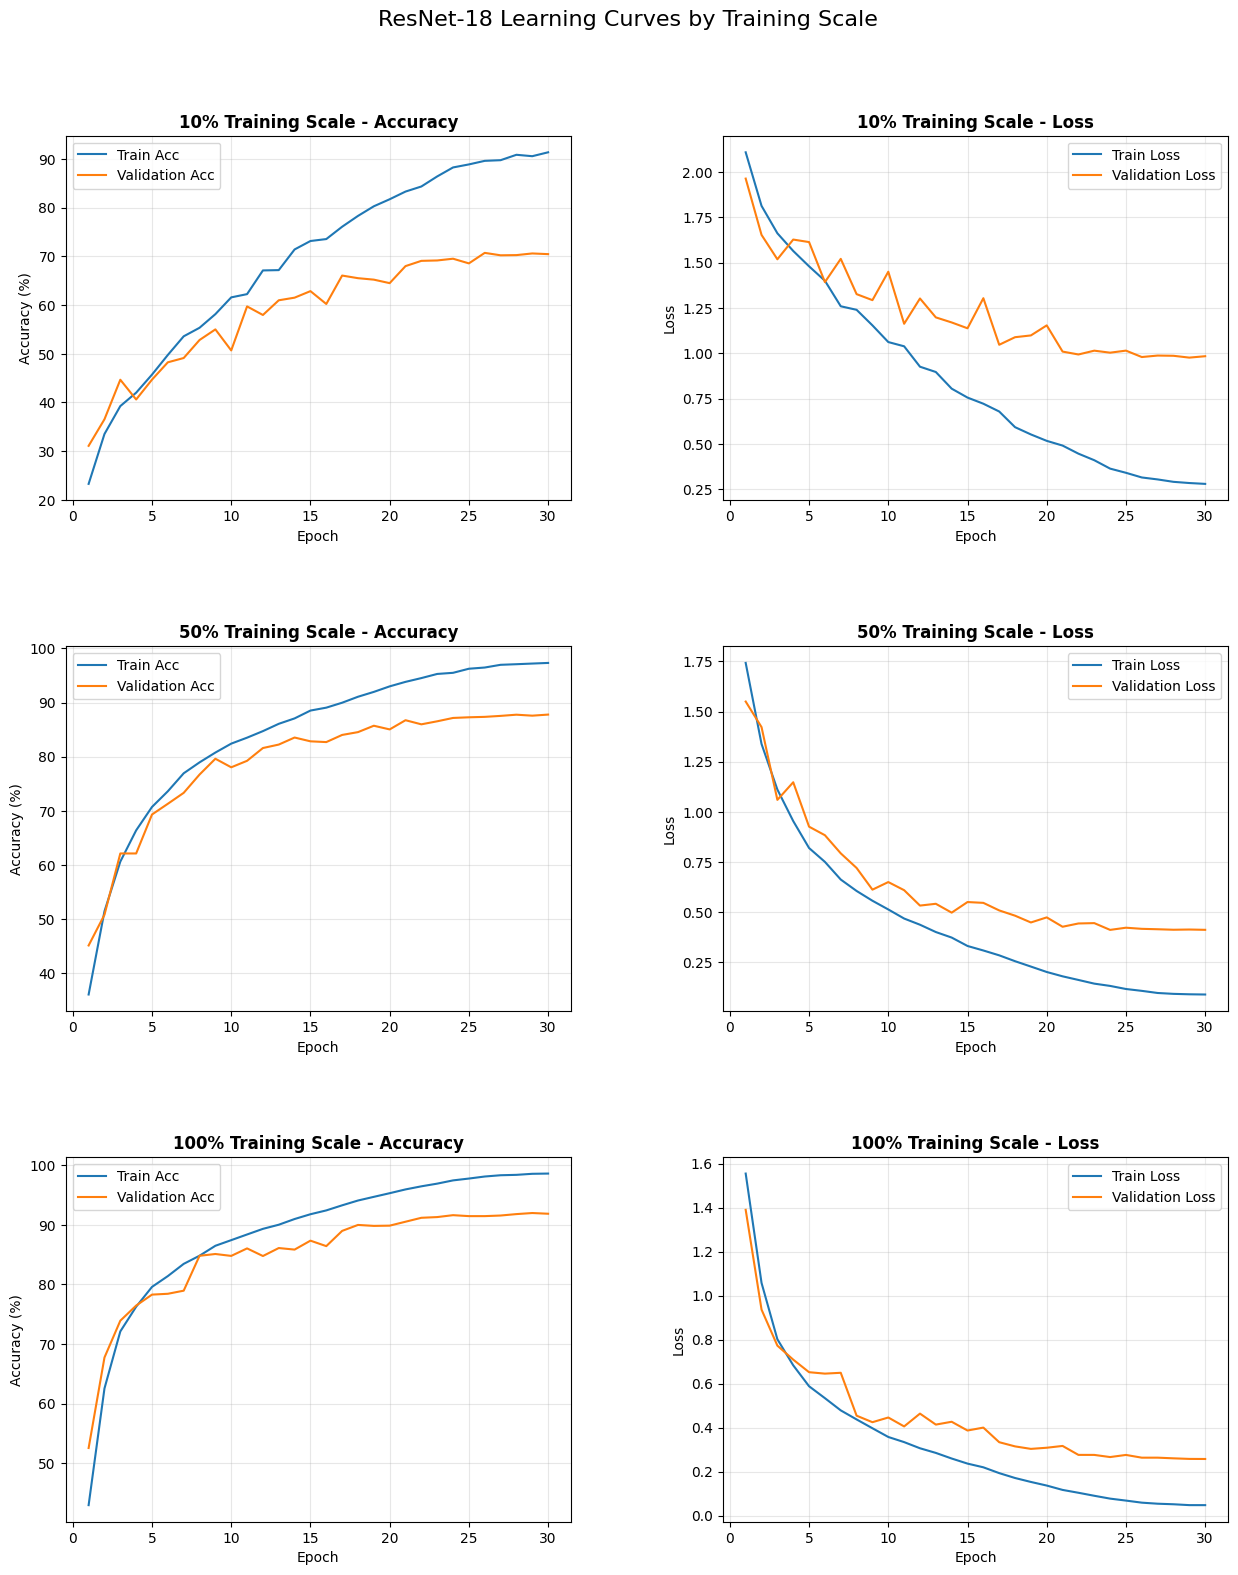

In [17]:
plt.rcParams.update({"font.size": 10})
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

titles = ["10% Training Scale", "50% Training Scale", "100% Training Scale"]

for i in range(3):
    history = results_cnn[i]
    epochs = history["epoch"]

    axes[i, 0].plot(epochs, history["train_acc"], label="Train Acc")
    axes[i, 0].plot(epochs, history["val_acc"], label="Validation Acc")
    axes[i, 0].set_title(f"{titles[i]} - Accuracy", fontweight="bold")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].set_ylabel("Accuracy (%)")
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(epochs, history["train_loss"], label="Train Loss")
    axes[i, 1].plot(epochs, history["val_loss"], label="Validation Loss")
    axes[i, 1].set_title(f"{titles[i]} - Loss", fontweight="bold")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 1].set_ylabel("Loss")
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.suptitle("ResNet-18 Learning Curves by Training Scale", fontsize=16, y=0.95)
plt.show()

### ResNet-18 learning-curve interpretation

- **10% data:** training accuracy reached 91.38% while validation accuracy was
  70.46% at epoch 30. The gap is evidence of overfitting, although validation
  accuracy was still improving late in training.
- **50% data:** the final train-validation gap narrowed to 9.54 points and the
  best validation checkpoint occurred at the final epoch.
- **100% data:** the final gap narrowed further to 6.75 points, with the best
  validation checkpoint at epoch 29.

The shrinking gap and rising test accuracy are consistent with improved
generalization as more training data becomes available. Because each condition
was run once, the exact differences should not be interpreted as confidence
intervals or seed-stable estimates.

### Train ViT model

In [18]:
from torchvision.models.vision_transformer import VisionTransformer

In [20]:
def get_cifar_vit_tiny():
    model = VisionTransformer(
        image_size=32,
        patch_size=4,
        num_layers=6,
        num_heads=3,
        hidden_dim=192,
        mlp_dim=768,
        num_classes=10,
        dropout=0.1,
        attention_dropout=0.1
    )
    return model

In [21]:
results_vit = {}

for i, scale in enumerate(scales):
    print("\n" + "-" * 40)
    print(f"ViT-Tiny training scale: {int(scale * 100)}%")
    print("-" * 40)

    vit = get_cifar_vit_tiny().to(device)
    optimizer = optim.AdamW(vit.parameters(), lr=3e-4, weight_decay=0.05)
    num_epochs = 30
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = fit_model(
        vit,
        trainloaders[i],
        optimizer,
        scheduler,
        criterion,
        device,
        num_epochs,
    )
    results_vit[i] = history
    test_loss, test_acc = evaluate(vit, testloader, criterion, device)
    results_vit[i]["test_loss"] = test_loss
    results_vit[i]["test_acc"] = test_acc
    torch.save(vit.state_dict(), f"vit_tiny_scale_{int(scale * 100)}_best.pth")
    print(
        f"Best validation epoch: {history['best_epoch']} | "
        f"Best validation accuracy: {history['best_val_acc']:.2f}% | "
        f"Final test accuracy: {test_acc:.2f}%"
    )


----------------------------------------
ViT-Tiny training scale: 10%
----------------------------------------
Epoch [1/30] - Train Loss: 2.1040, Train Acc: 21.20% - Val Loss: 2.0082, Val Acc: 24.94%
Epoch [2/30] - Train Loss: 1.9619, Train Acc: 25.31% - Val Loss: 1.8876, Val Acc: 28.40%
Epoch [3/30] - Train Loss: 1.8580, Train Acc: 29.31% - Val Loss: 1.8288, Val Acc: 31.84%
Epoch [4/30] - Train Loss: 1.8030, Train Acc: 31.51% - Val Loss: 1.7921, Val Acc: 32.22%
Epoch [5/30] - Train Loss: 1.7657, Train Acc: 32.24% - Val Loss: 1.7759, Val Acc: 32.24%
Epoch [10/30] - Train Loss: 1.6295, Train Acc: 38.47% - Val Loss: 1.7207, Val Acc: 37.08%
Epoch [15/30] - Train Loss: 1.4855, Train Acc: 44.98% - Val Loss: 1.5023, Val Acc: 44.70%
Epoch [20/30] - Train Loss: 1.3441, Train Acc: 50.73% - Val Loss: 1.4649, Val Acc: 47.32%
Epoch [25/30] - Train Loss: 1.2459, Train Acc: 55.11% - Val Loss: 1.4177, Val Acc: 49.40%
Epoch [30/30] - Train Loss: 1.2247, Train Acc: 55.96% - Val Loss: 1.4115, Val Acc: 

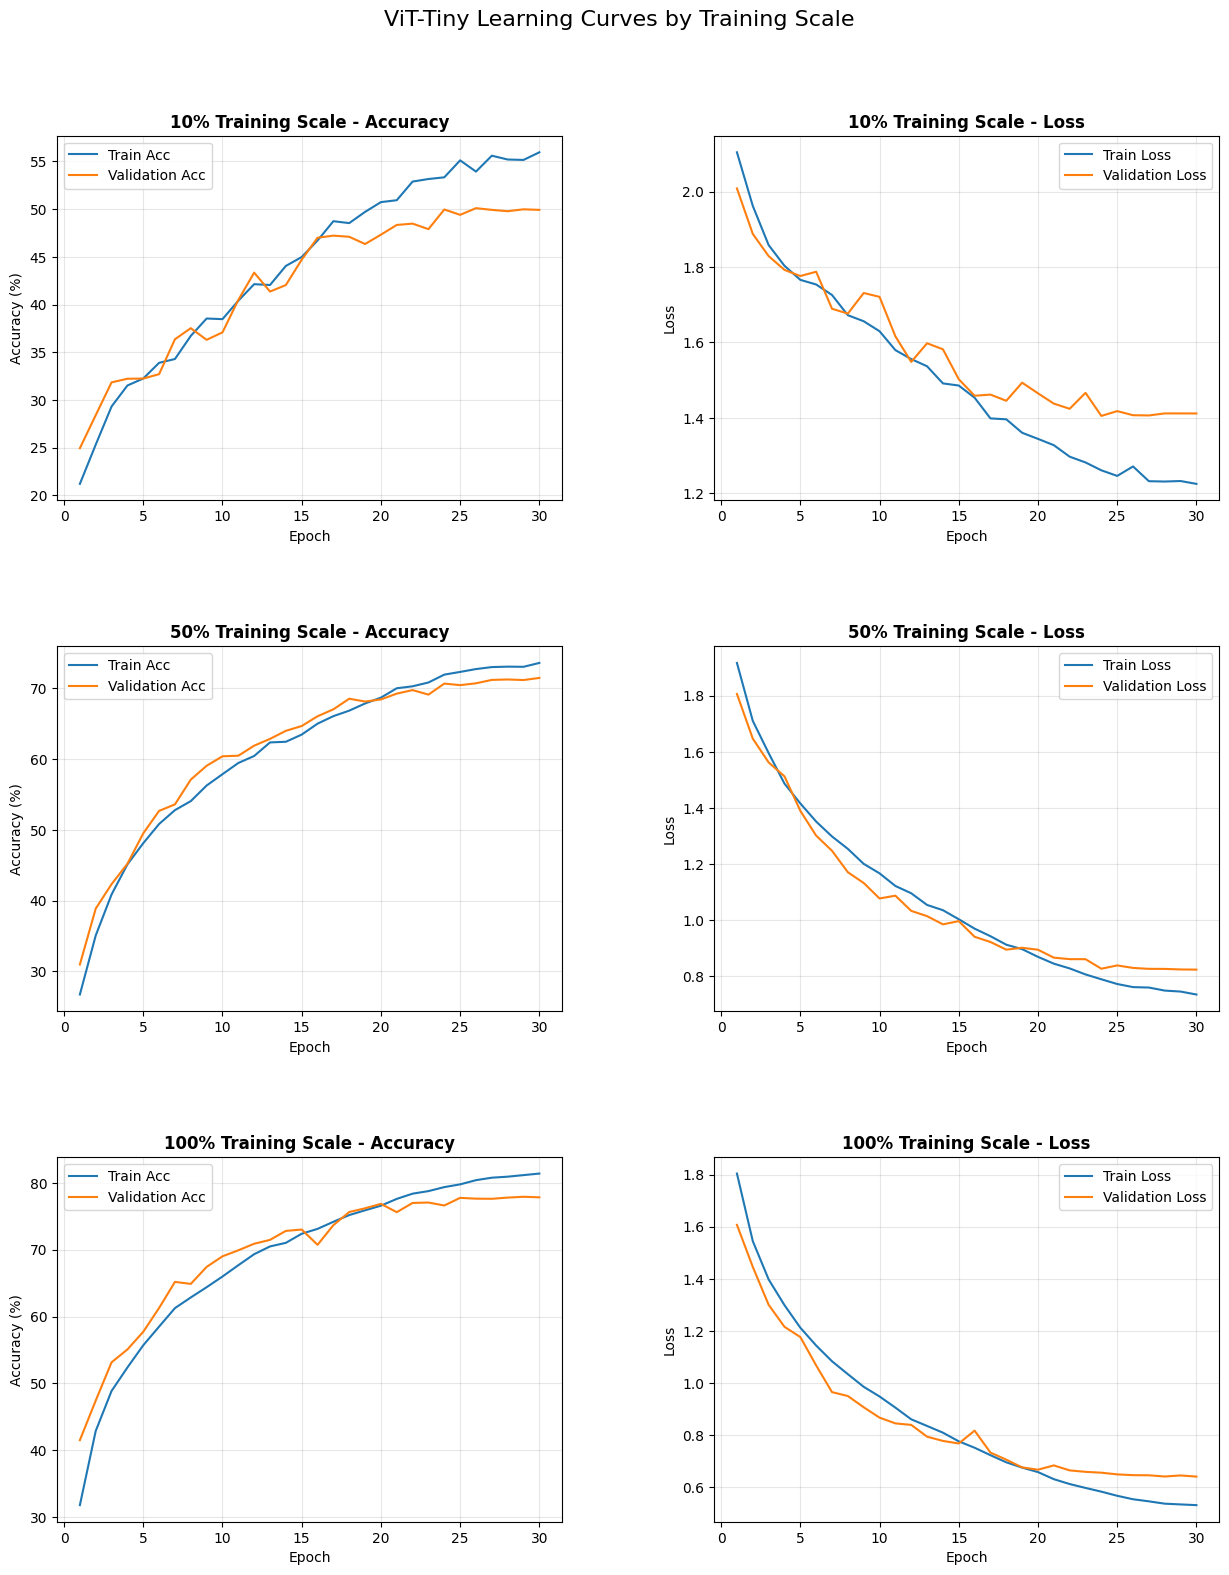

In [22]:
plt.rcParams.update({"font.size": 10})
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

titles = ["10% Training Scale", "50% Training Scale", "100% Training Scale"]

for i in range(3):
    history = results_vit[i]
    epochs = history["epoch"]

    axes[i, 0].plot(epochs, history["train_acc"], label="Train Acc")
    axes[i, 0].plot(epochs, history["val_acc"], label="Validation Acc")
    axes[i, 0].set_title(f"{titles[i]} - Accuracy", fontweight="bold")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].set_ylabel("Accuracy (%)")
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(epochs, history["train_loss"], label="Train Loss")
    axes[i, 1].plot(epochs, history["val_loss"], label="Validation Loss")
    axes[i, 1].set_title(f"{titles[i]} - Loss", fontweight="bold")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 1].set_ylabel("Loss")
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.suptitle("ViT-Tiny Learning Curves by Training Scale", fontsize=16, y=0.95)
plt.show()

### Baseline ViT-Tiny results and interpretation

| Training-pool share | Training images | Best validation epoch | Validation accuracy | Test accuracy |
|---:|---:|---:|---:|---:|
| 10% | 4,500 | 26 | 50.10% | 49.16% |
| 50% | 22,500 | 30 | 71.48% | 70.40% |
| 100% | 45,000 | 29 | 77.90% | 78.47% |

ViT-Tiny gained 29.31 test-accuracy points between the 10% and 100% subsets,
more than the 22.09-point gain observed for ResNet-18. Its deficit relative to
ResNet-18 therefore narrowed from 20.21 points at 10% data to 12.99 points at
100% data.

At 10% data, the baseline ViT ended at 55.96% training and 49.92% validation
accuracy. This is not the pattern of severe memorization seen in the 10%
ResNet run. Both curves remained comparatively low, and the best checkpoint
occurred late in training, so optimization difficulty and limited data are more
plausible explanations than overfitting alone.

### Follow-up experiment 1: longer ViT training with warmup

This experiment tests whether the 10% ViT result is limited by optimization.
It changes the training budget and schedule together, so it should be treated
as a diagnostic follow-up rather than a single-factor ablation.

In [23]:
vit = get_cifar_vit_tiny().to(device)
criterion_fallback1 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(vit.parameters(), lr=5e-4, weight_decay=0.05)
num_epochs = 50

warmup_epochs = 5
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs - warmup_epochs
)


class WarmupThenCosine:
    def __init__(self, optimizer, warmup_epochs, peak_lr, cosine_scheduler):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.peak_lr = peak_lr
        self.cosine_scheduler = cosine_scheduler
        self.epoch = 0

    def step(self):
        self.epoch += 1
        if self.epoch < self.warmup_epochs:
            next_lr = self.peak_lr * (self.epoch + 1) / self.warmup_epochs
            for group in self.optimizer.param_groups:
                group["lr"] = next_lr
        else:
            self.cosine_scheduler.step()


for group in optimizer.param_groups:
    group["lr"] = 5e-4 / warmup_epochs

scheduler = WarmupThenCosine(
    optimizer, warmup_epochs, 5e-4, cosine_scheduler
)

results_vit_fallback1 = fit_model(
    vit,
    trainloaders[0],
    optimizer,
    scheduler,
    criterion_fallback1,
    device,
    num_epochs,
)
torch.save(vit.state_dict(), "vit_tiny_longer_training_10pct_best.pth")

print(
    f"Best validation epoch: {results_vit_fallback1['best_epoch']} | "
    f"Best validation accuracy: {results_vit_fallback1['best_val_acc']:.2f}%"
)

Epoch [1/50] - Train Loss: 2.1988, Train Acc: 20.00% - Val Loss: 2.1023, Val Acc: 21.74%
Epoch [2/50] - Train Loss: 2.0676, Train Acc: 23.29% - Val Loss: 2.0149, Val Acc: 26.84%
Epoch [3/50] - Train Loss: 1.9898, Train Acc: 27.71% - Val Loss: 1.9809, Val Acc: 27.36%
Epoch [4/50] - Train Loss: 1.9713, Train Acc: 28.02% - Val Loss: 1.9346, Val Acc: 30.10%
Epoch [5/50] - Train Loss: 1.9414, Train Acc: 28.62% - Val Loss: 1.9085, Val Acc: 29.44%
Epoch [10/50] - Train Loss: 1.8097, Train Acc: 36.69% - Val Loss: 1.8115, Val Acc: 37.18%
Epoch [15/50] - Train Loss: 1.6913, Train Acc: 43.47% - Val Loss: 1.7370, Val Acc: 41.88%
Epoch [20/50] - Train Loss: 1.6104, Train Acc: 48.36% - Val Loss: 1.6550, Val Acc: 46.30%
Epoch [25/50] - Train Loss: 1.5085, Train Acc: 52.51% - Val Loss: 1.5794, Val Acc: 50.52%
Epoch [30/50] - Train Loss: 1.4393, Train Acc: 55.87% - Val Loss: 1.5423, Val Acc: 52.54%
Epoch [35/50] - Train Loss: 1.3572, Train Acc: 60.02% - Val Loss: 1.4983, Val Acc: 54.14%
Epoch [40/50] -

### Longer-training diagnostic result

The 50-epoch configuration with five warmup epochs, a higher peak learning
rate, and label smoothing reached **55.70% best validation accuracy** at epoch
45. This is 5.60 percentage points above the 30-epoch ViT baseline on the same
10% subset (50.10%). Training and validation accuracy both continued to improve,
supporting the claim that the baseline protocol left some optimization headroom.

This experiment changes four factors together—training duration, warmup,
learning rate, and label smoothing—so it is a diagnostic package, not a
single-variable ablation. It was selected and compared on validation data only;
no additional test result is reported.

### Follow-up experiment 2: stronger regularization

This experiment tests whether additional dropout, attention dropout, label
smoothing, and weight decay improve generalization at the 10% scale. Because
several regularization settings change together, the result identifies whether
the package helps, not which individual component caused the change.

In [24]:
# ### Regularized ViT-Tiny for fallback experiment

def get_cifar_vit_tiny_regularized():
    model = VisionTransformer(
        image_size=32,
        patch_size=4,
        num_layers=6,
        num_heads=3,
        hidden_dim=192,
        mlp_dim=768,
        num_classes=10,
        dropout=0.2,
        attention_dropout=0.2
    )
    return model


In [25]:
vit = get_cifar_vit_tiny_regularized().to(device)
criterion_fallback2 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(vit.parameters(), lr=3e-4, weight_decay=0.1)
num_epochs = 30
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

results_vit_fallback2 = fit_model(
    vit,
    trainloaders[0],
    optimizer,
    scheduler,
    criterion_fallback2,
    device,
    num_epochs,
)
torch.save(vit.state_dict(), "vit_tiny_regularized_10pct_best.pth")

print(
    f"Best validation epoch: {results_vit_fallback2['best_epoch']} | "
    f"Best validation accuracy: {results_vit_fallback2['best_val_acc']:.2f}%"
)

Epoch [1/30] - Train Loss: 2.1549, Train Acc: 20.31% - Val Loss: 2.0873, Val Acc: 22.72%
Epoch [2/30] - Train Loss: 2.0432, Train Acc: 24.22% - Val Loss: 2.0017, Val Acc: 28.24%
Epoch [3/30] - Train Loss: 1.9874, Train Acc: 27.36% - Val Loss: 1.9548, Val Acc: 29.64%
Epoch [4/30] - Train Loss: 1.9625, Train Acc: 29.04% - Val Loss: 1.9738, Val Acc: 27.72%
Epoch [5/30] - Train Loss: 1.9142, Train Acc: 30.60% - Val Loss: 1.9645, Val Acc: 30.46%
Epoch [10/30] - Train Loss: 1.8111, Train Acc: 36.71% - Val Loss: 1.8191, Val Acc: 37.60%
Epoch [15/30] - Train Loss: 1.7118, Train Acc: 41.96% - Val Loss: 1.7183, Val Acc: 42.54%
Epoch [20/30] - Train Loss: 1.6429, Train Acc: 45.84% - Val Loss: 1.6916, Val Acc: 45.56%
Epoch [25/30] - Train Loss: 1.5831, Train Acc: 48.51% - Val Loss: 1.6581, Val Acc: 46.34%
Epoch [30/30] - Train Loss: 1.5665, Train Acc: 49.67% - Val Loss: 1.6684, Val Acc: 46.20%
Best validation epoch: 27 | Best validation accuracy: 46.56%


### Stronger-regularization diagnostic result

The stronger-regularization package reached **46.56% best validation accuracy**,
3.54 points below the 10% ViT baseline. Its epoch-30 training accuracy was
49.67%, compared with 55.96% for the baseline. Because both fitting and
validation performance decreased, the package is more consistent with
additional underfitting than with improved generalization.

Dropout, attention dropout, label smoothing, and weight decay were changed
together. The result therefore rejects this package under the present budget;
it does not identify which individual regularizer caused the decline.

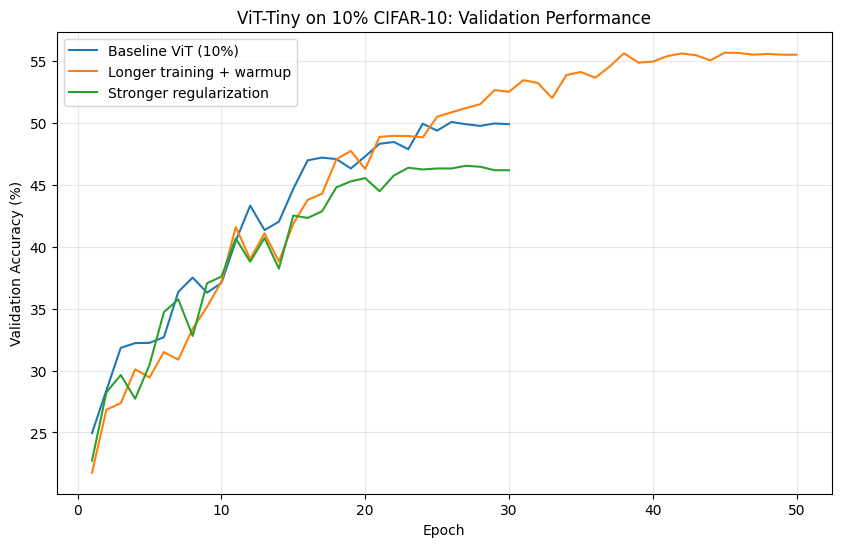

In [26]:
plt.figure(figsize=(10, 6))

baseline = results_vit[0]
plt.plot(baseline["epoch"], baseline["val_acc"], label="Baseline ViT (10%)")
plt.plot(
    results_vit_fallback1["epoch"],
    results_vit_fallback1["val_acc"],
    label="Longer training + warmup",
)
plt.plot(
    results_vit_fallback2["epoch"],
    results_vit_fallback2["val_acc"],
    label="Stronger regularization",
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("ViT-Tiny on 10% CIFAR-10: Validation Performance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Findings and evidence boundary

### Main comparison

| Training-pool share | ResNet-18 test accuracy | ViT-Tiny test accuracy | ResNet advantage |
|---:|---:|---:|---:|
| 10% | 69.37% | 49.16% | 20.21 points |
| 50% | 87.19% | 70.40% | 16.79 points |
| 100% | 91.46% | 78.47% | 12.99 points |

Under the documented model-specific training protocols, ResNet-18 generalized
better at every observed data scale. The gap narrowed as the training set grew,
while ViT-Tiny obtained the larger absolute gain from additional data. This is
consistent with the convolutional model being more data-efficient in this
small-image, from-scratch setting.

The 10% ViT result cannot be explained by one factor alone. Longer training and
warmup improved validation accuracy by 5.60 points, showing that optimization
contributed to the original gap. However, the improved validation result still
remained 15.02 points below the 10% ResNet validation result. Stronger
regularization reduced both training and validation performance, so excess
regularization did not solve the problem.

### What this experiment does not establish

- It does not isolate architecture as the only causal factor: ResNet-18 and
  ViT-Tiny differ in capacity, inductive bias, optimizer, and learning-rate
  protocol.
- Results come from one model-training run per condition. The split is fixed,
  but model initialization, minibatch order, and GPU kernels were not evaluated
  across multiple random seeds.
- The follow-up configurations change multiple hyperparameters together and are
  diagnostic comparisons rather than controlled ablations.
- The experiment covers CIFAR-10, 32×32 images, and training from scratch; it
  does not support claims about large-scale data or pretrained transformers.

### Highest-value next experiments

1. Repeat every baseline condition with at least three full random seeds and
   report mean ± standard deviation.
2. Report trainable parameter counts, training time, and peak GPU memory, then
   add a capacity-matched CNN/ViT comparison.
3. Separate the longer-training package into controlled ablations for epochs,
   warmup, learning rate, and label smoothing.
4. Compare training from scratch with pretrained fine-tuning for both model
   families.
5. Add per-class accuracy and confusion matrices to test whether the
   architectures fail on different visual categories.